# ERA5-Land vs GSHTD 1km Daily Tmax — 4-City Comparison (2003–2020)

Compares two **independent** temperature datasets over the shared 2003–2020 period:

| Product | Resolution | Source |
|---|---|---|
| **ERA5-Land** (`ECMWF/ERA5_LAND/HOURLY`, band `temperature_2m`) | ~0.1° (~9 km) | ECMWF land-only reanalysis via GEE |
| **GSHTD** (Zhang et al. 2022, band `b1`) | 1 km | Observation-based daily temperature dataset via GEE |

ERA5-Land is the correct product for this comparison:
- **Land-only** — ocean pixels are not included, eliminating the coastal mixing bias that
  affects the coarser `ECMWF/ERA5/DAILY` (0.25°/28 km) product
- **Higher resolution** (~9 km vs ~28 km) — better matches the GSHTD domain footprint
- Daily max is computed from the **hourly** collection (max over 24 UTC hours per day)

**Four cities:** Salvador · Teresina · Cáceres · Fortaleza (all Brazil)

**Spatial aggregation method:** GSHTD 1km pixels are block-averaged (simple mean) within
each ERA5-Land pixel footprint before pixel-level comparison.

**Prerequisites:**
- GSHTD Tmax cached for Salvador, Teresina, Cáceres (`data/{city}_tmax.nc`) → run `01_data_acquisition.ipynb`
- ERA5-Land files downloaded in **Section 1** below (requires GEE auth, ~5–10 min per city)
- GSHTD for Fortaleza downloaded in **Section 1.4** (requires GEE auth, ~10–20 min)

In [17]:
# ── Configuration — edit here ──────────────────────────────────────────────────────

GEE_PROJECT    = "tl-cities"
DATA_DIR       = "data"       # GSHTD cache (relative to this notebook)
ERA5_DIR       = "../data"    # ERA5-Land cache  (relative to this notebook)
OUTPUT_DIR     = "../outputs"
ANALYSIS_START = "2003-01-01"
ANALYSIS_END   = "2020-12-31"

# ERA5-Land download params
ERA5_COLLECTION  = "ECMWF/ERA5_LAND/HOURLY"   # hourly; daily max computed server-side
ERA5_TX_BAND     = "temperature_2m"             # band name in the hourly collection (Kelvin)
ERA5_SCALE_M     = 11132                        # native resolution (~0.1°)
ERA5_BUFFER_DEG  = 0.5                          # degrees of padding around city centre
ERA5LAND_VAR     = "tx2m_max"                   # variable name saved in output NetCDF (°C)
ERA5_DL_START    = "2003-01-01"                 # only need analysis period for ERA5-Land
ERA5_DL_END      = "2021-01-01"

# Study cities — Salvador / Teresina / Cáceres have GSHTD cached; Fortaleza needs both.
COMPARISON_CITIES = {
    "salvador": {
        "label":      "Salvador, Brazil",
        "center":     (-12.97, -38.51),
        "bbox":       {"west": -38.8, "east": -38.2, "south": -13.2, "north": -12.7},
        "collection": "projects/sat-io/open-datasets/global-daily-air-temp/latin_america",
        "era5_nc":    "era5land_tx_daily_salvador_brazil.nc",
        "gshtd_nc":   "salvador_tmax.nc",    # pre-cached
    },
    "teresina": {
        "label":      "Teresina, Brazil",
        "center":     (-5.09, -42.80),
        "bbox":       {"west": -43.2, "east": -42.5, "south": -5.4, "north": -4.8},
        "collection": "projects/sat-io/open-datasets/global-daily-air-temp/latin_america",
        "era5_nc":    "era5land_tx_daily_teresina_brazil.nc",
        "gshtd_nc":   "teresina_tmax.nc",    # pre-cached
    },
    "caceres": {
        "label":      "Cáceres, Brazil",
        "center":     (-16.07, -57.68),
        "bbox":       {"west": -58.1, "east": -57.3, "south": -16.5, "north": -15.7},
        "collection": "projects/sat-io/open-datasets/global-daily-air-temp/latin_america",
        "era5_nc":    "era5land_tx_daily_caceres_brazil.nc",
        "gshtd_nc":   "caceres_tmax.nc",     # pre-cached
    },
    "fortaleza": {
        "label":      "Fortaleza, Brazil",
        "center":     (-3.73, -38.52),
        "bbox":       {"west": -38.75, "east": -38.25, "south": -4.0, "north": -3.5},
        "collection": "projects/sat-io/open-datasets/global-daily-air-temp/latin_america",
        "era5_nc":    "era5land_tx_daily_fortaleza_brazil.nc",
        "gshtd_nc":   "fortaleza_tmax.nc",   # downloaded in Section 1.4
    },
}

CITY_COLORS = {
    "salvador":  "#1f77b4",
    "teresina":  "#ff7f0e",
    "caceres":   "#2ca02c",
    "fortaleza": "#d62728",
}

print("Study cities:")
for k, v in COMPARISON_CITIES.items():
    print(f"  {k:12s}  {v['label']}  centre {v['center']}")
print(f"\nAnalysis period : {ANALYSIS_START} to {ANALYSIS_END}")
print(f"ERA5-Land       : {ERA5_COLLECTION}  |  {ERA5_SCALE_M} m  |  ±{ERA5_BUFFER_DEG}° buffer")

Study cities:
  salvador      Salvador, Brazil  centre (-12.97, -38.51)
  teresina      Teresina, Brazil  centre (-5.09, -42.8)
  caceres       Cáceres, Brazil  centre (-16.07, -57.68)
  fortaleza     Fortaleza, Brazil  centre (-3.73, -38.52)

Analysis period : 2003-01-01 to 2020-12-31
ERA5-Land       : ECMWF/ERA5_LAND/HOURLY  |  11132 m  |  ±0.5° buffer


In [18]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

sys.path.insert(0, ".")
from utils.heat import load_city   # reuse existing GSHTD loader

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

print(f"xarray  {xr.__version__}")
print(f"numpy   {np.__version__}")
print(f"pandas  {pd.__version__}")

xarray  2024.7.0
numpy   1.26.4
pandas  2.3.1


## Section 1 — ERA5-Land Acquisition

Downloads `temperature_2m` from `ECMWF/ERA5_LAND/HOURLY` and computes the **daily
maximum** server-side (max over all 24 UTC hours per day) before retrieving via
`getRegion()`. Output files are saved in `°C` as `{ERA5LAND_VAR}`.

Cells are **idempotent** — re-running skips cities whose `.nc` already exists.
All four cities need a fresh download (ERA5-Land files are separate from
the `ECMWF/ERA5/DAILY` files used in earlier notebooks).

In [19]:
import ee

ee.Initialize(project=GEE_PROJECT)
print(f"GEE initialised  (project: {GEE_PROJECT})")


def _era5land_valid(path: Path, varname: str = ERA5LAND_VAR) -> bool:
    if not path.exists():
        return False
    try:
        ds = xr.open_dataset(path)
        ok = varname in ds
        ds.close()
        return ok
    except Exception:
        return False


def _is_leap(yr: int) -> bool:
    return yr % 4 == 0 and (yr % 100 != 0 or yr % 400 == 0)


def download_era5land(city_key: str, cfg: dict, era5_dir: str) -> None:
    """
    Download ERA5-Land daily max 2m temperature from the HOURLY collection.

    Strategy: for each year, build a server-side ImageCollection of daily-max images
    (one image per day = max over all 24 UTC hours), then retrieve with getRegion().
    Ocean pixels are absent from ERA5-Land so no land-mask step is needed.
    Idempotent — skips if output file already exists and contains the expected variable.
    """
    out = Path(era5_dir) / cfg["era5_nc"]
    if _era5land_valid(out):
        sz = out.stat().st_size / 1e6
        print(f"{city_key}: ERA5-Land cached at {out}  ({sz:.1f} MB) — skipping.")
        return

    lat, lon = cfg["center"]
    buf = ERA5_BUFFER_DEG
    roi = ee.Geometry.Rectangle([lon - buf, lat - buf, lon + buf, lat + buf])

    hourly_col = (
        ee.ImageCollection(ERA5_COLLECTION)
          .select(ERA5_TX_BAND)
          .filterBounds(roi)
    )

    print(f"{city_key}: building ERA5-Land daily-max collection and downloading ...")
    frames = []

    for yr in range(int(ERA5_DL_START[:4]), int(ERA5_DL_END[:4])):
        n_days    = 366 if _is_leap(yr) else 365
        start_str = f"{yr}-01-01"
        start_ee  = ee.Date(start_str)

        # Filter hourly images for this year
        yr_hourly = hourly_col.filterDate(start_str, f"{yr + 1}-01-01")

        # Server-side: create one image per day = max over that day's 24 hourly images
        date_seq  = ee.List.sequence(0, n_days - 1)

        def _daily_max(offset):
            d = start_ee.advance(offset, "day")
            return (
                yr_hourly
                  .filterDate(d, d.advance(1, "day"))
                  .max()                             # max across hours → Kelvin
                  .set("system:time_start", d.millis())
            )

        daily_col = ee.ImageCollection(date_seq.map(_daily_max))

        try:
            rows = daily_col.getRegion(roi, ERA5_SCALE_M).getInfo()
        except Exception as exc:
            print(f"  {yr}: skipped — {exc}")
            continue

        if len(rows) <= 1:
            continue

        df_yr = (
            pd.DataFrame(rows[1:], columns=rows[0])
              .dropna(subset=[ERA5_TX_BAND])
        )
        df_yr["time"]  = pd.to_datetime(df_yr["time"], unit="ms").dt.normalize()
        df_yr["tx_c"]  = df_yr[ERA5_TX_BAND].astype(float) - 273.15   # K → °C
        frames.append(df_yr[["time", "latitude", "longitude", "tx_c"]])
        print(f"  {yr}: {len(df_yr):>7,} pixel-day rows", end="\r")

    if not frames:
        raise RuntimeError(f"{city_key}: no ERA5-Land data retrieved.")

    print(f"\n{city_key}: assembling ...")
    df = (
        pd.concat(frames, ignore_index=True)
          .rename(columns={"latitude": "lat", "longitude": "lon"})
          .drop_duplicates(subset=["time", "lat", "lon"])
    )
    lats  = np.sort(df["lat"].unique())
    lons  = np.sort(df["lon"].unique())
    times = np.sort(df["time"].unique())
    full_idx = pd.MultiIndex.from_product([times, lats, lons], names=["time", "lat", "lon"])
    arr = (
        df.set_index(["time", "lat", "lon"])["tx_c"]
          .reindex(full_idx).values
          .reshape(len(times), len(lats), len(lons)).astype(np.float32)
    )
    da = xr.DataArray(
        arr, dims=["time", "lat", "lon"],
        coords={"time": pd.DatetimeIndex(times), "lat": lats, "lon": lons},
        attrs={
            "units":      "°C",
            "long_name":  "ERA5-Land daily max 2 m temperature",
            "source":     ERA5_COLLECTION,
            "processing": "Daily max of hourly temperature_2m (max over 24 UTC hours)",
        },
    )
    out.parent.mkdir(parents=True, exist_ok=True)
    da.to_dataset(name=ERA5LAND_VAR).to_netcdf(
        out, encoding={ERA5LAND_VAR: {"dtype": "float32", "zlib": True, "complevel": 4}}
    )
    sz = out.stat().st_size / 1e6
    print(f"{city_key}: saved {out}  ({sz:.1f} MB, {len(lats)}×{len(lons)} grid, {len(times)} days)")

GEE initialised  (project: tl-cities)


In [20]:
download_era5land("salvador", COMPARISON_CITIES["salvador"], ERA5_DIR)

salvador: building ERA5-Land daily-max collection and downloading ...
  2020:  13,542 pixel-day rows
salvador: assembling ...
salvador: saved ../data/era5land_tx_daily_salvador_brazil.nc  (0.8 MB, 9×10 grid, 6575 days)


In [21]:
download_era5land("teresina", COMPARISON_CITIES["teresina"], ERA5_DIR)

teresina: building ERA5-Land daily-max collection and downloading ...
  2020:  36,600 pixel-day rows
teresina: assembling ...
teresina: saved ../data/era5land_tx_daily_teresina_brazil.nc  (1.2 MB, 10×10 grid, 6575 days)


In [22]:
download_era5land("caceres", COMPARISON_CITIES["caceres"], ERA5_DIR)

caceres: building ERA5-Land daily-max collection and downloading ...
  2020:  36,600 pixel-day rows
caceres: assembling ...
caceres: saved ../data/era5land_tx_daily_caceres_brazil.nc  (1.3 MB, 10×10 grid, 6575 days)


In [23]:
download_era5land("fortaleza", COMPARISON_CITIES["fortaleza"], ERA5_DIR)

fortaleza: building ERA5-Land daily-max collection and downloading ...
  2020:  18,300 pixel-day rows
fortaleza: assembling ...
fortaleza: saved ../data/era5land_tx_daily_fortaleza_brazil.nc  (0.9 MB, 9×10 grid, 6575 days)


## Section 1.4 — GSHTD 1km Acquisition: Fortaleza

Downloads daily Tmax from the **Zhang et al. (2022) GSHTD** dataset (`b1 / 10 = °C`)
for Fortaleza. Salvador, Teresina and Cáceres already have cached files in `data/`.

**Expected runtime:** 10–20 minutes. The cell is idempotent — skip if `data/fortaleza_tmax.nc` exists.

In [24]:
def download_gshtd(city_key: str, cfg: dict, data_dir: str,
                   start: str = ANALYSIS_START, end: str = ANALYSIS_END,
                   resolution: int = 1000) -> None:
    """Download GSHTD 1km daily Tmax from GEE and cache as NetCDF. Idempotent."""
    out = Path(data_dir) / cfg["gshtd_nc"]
    if out.exists():
        sz = out.stat().st_size / 1e6
        print(f"{city_key}: GSHTD already cached at {out}  ({sz:.1f} MB) — skipping.")
        return

    bbox = cfg["bbox"]
    roi  = ee.Geometry.Rectangle([bbox["west"], bbox["south"], bbox["east"], bbox["north"]])
    col  = (
        ee.ImageCollection(cfg["collection"])
          .filterDate(start, end)
          .filterBounds(roi)
    )
    n_img = col.size().getInfo()
    print(f"{city_key}: {n_img} GSHTD images — downloading in 90-day chunks ...")

    time_idx = pd.date_range(start, end, freq="D")
    frames, chunk = [], 90

    for i in range(0, len(time_idx), chunk):
        t0 = time_idx[i].strftime("%Y-%m-%d")
        t1 = time_idx[min(i + chunk, len(time_idx) - 1)].strftime("%Y-%m-%d")
        try:
            rows = (
                col.filterDate(t0, t1)
                   .getRegion(roi, resolution)
                   .getInfo()
            )
            df_c = pd.DataFrame(rows[1:], columns=rows[0]).dropna(subset=["b1"])
            df_c["time"] = pd.to_datetime(df_c["time"], unit="ms").dt.normalize()
            df_c["tmax"] = df_c["b1"].astype(float) / 10.0
            frames.append(df_c[["time", "latitude", "longitude", "tmax"]])
            print(f"  chunk {i // chunk + 1:3d}: {len(df_c):>7,} rows ({t0} – {t1})", end="\r")
        except Exception as exc:
            print(f"  chunk {i // chunk + 1}: error — {exc}")

    if not frames:
        raise RuntimeError(f"{city_key}: no GSHTD data retrieved.")

    print(f"\n{city_key}: assembling ...")
    df = (
        pd.concat(frames, ignore_index=True)
          .rename(columns={"latitude": "lat", "longitude": "lon"})
          .drop_duplicates(subset=["time", "lat", "lon"])
    )
    lats  = np.sort(df["lat"].unique())
    lons  = np.sort(df["lon"].unique())
    times = np.sort(df["time"].unique())
    full_idx = pd.MultiIndex.from_product([times, lats, lons], names=["time", "lat", "lon"])
    arr = (
        df.set_index(["time", "lat", "lon"])["tmax"]
          .reindex(full_idx).values
          .reshape(len(times), len(lats), len(lons)).astype(np.float32)
    )
    da = xr.DataArray(
        arr, dims=["time", "lat", "lon"],
        coords={"time": pd.DatetimeIndex(times), "lat": lats, "lon": lons},
        attrs={"units": "degC", "source": "GSHTD / Zhang et al. (2022)"},
    )
    out.parent.mkdir(parents=True, exist_ok=True)
    da.to_dataset(name="tmax").to_netcdf(
        out, encoding={"tmax": {"dtype": "float32", "zlib": True, "complevel": 4}}
    )
    sz = out.stat().st_size / 1e6
    print(f"{city_key}: saved {out}  ({sz:.1f} MB)")


download_gshtd("fortaleza", COMPARISON_CITIES["fortaleza"], DATA_DIR)

fortaleza: GSHTD already cached at data/fortaleza_tmax.nc  (7.9 MB) — skipping.


## Section 2 — Load Data

Loads ERA5 and GSHTD for all available cities, clips to the analysis period,
and clips the ERA5 grid to each city's GSHTD spatial footprint for apples-to-apples
area-mean comparisons.

In [25]:
era5_data    = {}   # full ERA5-Land DataArray per city (time, lat, lon), °C
gshtd_data   = {}   # GSHTD 1km DataArray per city (time, lat, lon), °C
era5_in_bbox = {}   # ERA5-Land pixels within the GSHTD bbox

_GSHTD_NATIVE = {"salvador", "teresina", "caceres"}  # loaded via load_city()

for city, cfg in COMPARISON_CITIES.items():
    era5_path  = Path(ERA5_DIR)  / cfg["era5_nc"]
    gshtd_path = Path(DATA_DIR)  / cfg["gshtd_nc"]

    missing = []
    if not era5_path.exists():  missing.append(f"ERA5-Land ({era5_path})")
    if not gshtd_path.exists(): missing.append(f"GSHTD ({gshtd_path})")
    if missing:
        print(f"{city}: SKIPPED — missing {', '.join(missing)}")
        continue

    # ── Load ERA5-Land (already in °C, land pixels only) ─────────────────────
    ds_era5 = xr.open_dataset(era5_path)
    tx_era5 = ds_era5[ERA5LAND_VAR].sel(time=slice(ANALYSIS_START, ANALYSIS_END))
    tx_era5.attrs.update({"units": "°C", "long_name": "ERA5-Land daily max 2 m temperature",
                           "source": ERA5_COLLECTION})
    era5_data[city] = tx_era5

    # ── Load GSHTD 1km ───────────────────────────────────────────────────────
    if city in _GSHTD_NATIVE:
        gshtd = load_city(city, DATA_DIR).sel(time=slice(ANALYSIS_START, ANALYSIS_END))
    else:
        gshtd = xr.open_dataset(gshtd_path)["tmax"].sel(time=slice(ANALYSIS_START, ANALYSIS_END))
    gshtd_data[city] = gshtd

    # ── Clip ERA5-Land to GSHTD spatial footprint ─────────────────────────────
    g_lat_min, g_lat_max = float(gshtd.lat.min()), float(gshtd.lat.max())
    g_lon_min, g_lon_max = float(gshtd.lon.min()), float(gshtd.lon.max())
    era5_sorted = tx_era5.sortby("lat").sortby("lon")
    # half-cell buffer at ~0.05° (half of 0.1° ERA5-Land spacing)
    era5_in_bbox[city] = era5_sorted.sel(
        lat=slice(g_lat_min - 0.06, g_lat_max + 0.06),
        lon=slice(g_lon_min - 0.06, g_lon_max + 0.06),
    )

    # Common time axis
    common = np.intersect1d(era5_in_bbox[city].time.values, gshtd.time.values)
    era5_in_bbox[city] = era5_in_bbox[city].sel(time=common)
    gshtd_data[city]   = gshtd_data[city].sel(time=common)

    print(f"{cfg['label']}:")
    print(f"  ERA5-Land (in GSHTD bbox): {era5_in_bbox[city].lat.size} × "
          f"{era5_in_bbox[city].lon.size} cells  | "
          f"{era5_in_bbox[city].time.size} days  | "
          f"{float(era5_in_bbox[city].mean()):.1f} °C mean")
    print(f"  GSHTD 1km               : {gshtd.lat.size} × {gshtd.lon.size} pixels | "
          f"{gshtd_data[city].time.size} days  | "
          f"{float(gshtd_data[city].mean()):.1f} °C mean")

AVAILABLE = list(era5_in_bbox.keys())
print(f"\nDatasets ready: {AVAILABLE}")

salvador: shape {'time': 6497, 'lat': 55, 'lon': 67}  2003-01-01 to 2020-12-30
Salvador, Brazil:
  ERA5-Land (in GSHTD bbox): 6 × 8 cells  | 6497 days  | 27.5 °C mean
  GSHTD 1km               : 55 × 67 pixels | 6497 days  | 30.3 °C mean
teresina: shape {'time': 6497, 'lat': 67, 'lon': 78}  2003-01-01 to 2020-12-30
Teresina, Brazil:
  ERA5-Land (in GSHTD bbox): 8 × 9 cells  | 6497 days  | 32.8 °C mean
  GSHTD 1km               : 67 × 78 pixels | 6497 days  | 33.2 °C mean
caceres: shape {'time': 6497, 'lat': 89, 'lon': 89}  2003-01-01 to 2020-12-30
Cáceres, Brazil:
  ERA5-Land (in GSHTD bbox): 10 × 10 cells  | 6497 days  | 31.1 °C mean
  GSHTD 1km               : 89 × 89 pixels | 6497 days  | 31.9 °C mean
Fortaleza, Brazil:
  ERA5-Land (in GSHTD bbox): 5 × 6 cells  | 6570 days  | 30.2 °C mean
  GSHTD 1km               : 43 × 56 pixels | 6570 days  | 32.6 °C mean

Datasets ready: ['salvador', 'teresina', 'caceres', 'fortaleza']


## Section 3 — Spatial Aggregation: GSHTD 1km → ERA5-Land Grid

**Method — block average (simple mean):**
For each ERA5-Land pixel (~9 km), all GSHTD 1km pixels whose centre falls within
that pixel's footprint are averaged (no area-weighting; pixels are nearly equal-area
at these tropical latitudes). At ~9 km ERA5-Land spacing each cell contains roughly
~9 × 9 ≈ 81 GSHTD 1km pixels — enough for the block average to be stable.

**Why not area-weighted mean?**
Cos(lat) weighting would differ by <0.1% across these small tropical domains.

**ERA5-Land advantage here:** ocean pixels are absent from the ERA5-Land grid,
so no land-masking is needed before aggregation — coastal cells contain only land values.

In [26]:
def aggregate_gshtd_to_era5(gshtd_da: xr.DataArray, era5_da: xr.DataArray) -> xr.DataArray:
    """
    Block-average 1km GSHTD onto the ERA5 pixel grid.

    For each ERA5 cell, compute the mean of every GSHTD pixel whose centre lies
    within that cell's footprint (defined by midpoints between adjacent ERA5 centres).
    The loop over coarse cells is small (~4–64 cells); all time steps are vectorised.

    Parameters
    ----------
    gshtd_da : xr.DataArray (time, lat, lon) — 1km daily Tmax, °C
    era5_da  : xr.DataArray (time, lat, lon) — ERA5 daily Tmax, defines target grid

    Returns
    -------
    xr.DataArray (time, lat, lon) — GSHTD spatially averaged to ERA5 grid
    """
    era5_lats = np.sort(era5_da.lat.values)
    era5_lons = np.sort(era5_da.lon.values)

    dlat = np.median(np.diff(era5_lats)) if len(era5_lats) > 1 else 0.25
    dlon = np.median(np.diff(era5_lons)) if len(era5_lons) > 1 else 0.25

    # Cell-boundary edges (midpoints between adjacent ERA5 cell centres)
    lat_edges = np.concatenate(
        [[era5_lats[0] - dlat / 2],
         (era5_lats[:-1] + era5_lats[1:]) / 2,
         [era5_lats[-1] + dlat / 2]]
    )
    lon_edges = np.concatenate(
        [[era5_lons[0] - dlon / 2],
         (era5_lons[:-1] + era5_lons[1:]) / 2,
         [era5_lons[-1] + dlon / 2]]
    )

    # Clip GSHTD to ERA5 bounding box
    gshtd_sub = gshtd_da.sel(
        lat=slice(lat_edges.min(), lat_edges.max()),
        lon=slice(lon_edges.min(), lon_edges.max()),
    )
    if gshtd_sub.lat.size == 0 or gshtd_sub.lon.size == 0:
        raise ValueError(
            "No GSHTD pixels found within the ERA5 bounding box. "
            "Check that ERA5 was downloaded with a sufficient ROI buffer."
        )

    fine_lats = gshtd_sub.lat.values  # (nlat_fine,)
    fine_lons = gshtd_sub.lon.values  # (nlon_fine,)

    # Assign each fine pixel to its coarse ERA5 cell (0-indexed)
    lat_bin = np.clip(np.digitize(fine_lats, lat_edges) - 1, 0, len(era5_lats) - 1)
    lon_bin = np.clip(np.digitize(fine_lons, lon_edges) - 1, 0, len(era5_lons) - 1)
    flat_bin = (lat_bin[:, None] * len(era5_lons) + lon_bin[None, :]).ravel()  # (n_fine,)

    n_coarse = len(era5_lats) * len(era5_lons)
    vals = gshtd_sub.values.reshape(gshtd_sub.shape[0], -1)  # (time, n_fine)

    unique_bins = np.unique(flat_bin)
    result = np.full((gshtd_sub.shape[0], n_coarse), np.nan, dtype=np.float32)

    # Vectorised over all time steps; loop only over unique coarse bins (~4–64)
    for b in unique_bins:
        mask = flat_bin == b
        result[:, b] = np.nanmean(vals[:, mask], axis=1)

    result = result.reshape(gshtd_sub.shape[0], len(era5_lats), len(era5_lons))

    # Keep only ERA5 cells that actually contained GSHTD pixels
    covered_lat = np.array([np.any(lat_bin == i) for i in range(len(era5_lats))])
    covered_lon = np.array([np.any(lon_bin == j) for j in range(len(era5_lons))])

    n_px_avg = vals.shape[1] / max(len(unique_bins), 1)
    n_cells  = covered_lat.sum() * covered_lon.sum()
    print(
        f"  Aggregation: {gshtd_sub.lat.size}×{gshtd_sub.lon.size} fine px "
        f"→ {covered_lat.sum()}×{covered_lon.sum()} ERA5 cells "
        f"(~{n_px_avg:.0f} fine px/cell avg, {n_cells} cells total)"
    )

    return xr.DataArray(
        result[:, covered_lat, :][:, :, covered_lon],
        dims=["time", "lat", "lon"],
        coords={
            "time": gshtd_sub.time,
            "lat":  era5_lats[covered_lat],
            "lon":  era5_lons[covered_lon],
        },
        attrs={
            "units":       "°C",
            "long_name":   "GSHTD 1km Tmax block-averaged to ERA5 grid",
            "aggregation": f"Simple spatial mean of ~{n_px_avg:.0f} fine pixels per ERA5 cell",
        },
    )


# Apply to all available cities
gshtd_agg = {}   # GSHTD averaged to ERA5 grid, for pixel-level comparison
era5_matched = {} # ERA5 restricted to covered cells, aligned time

print("Block-averaging GSHTD 1km → ERA5 grid ...\n")
for city in AVAILABLE:
    cfg = COMPARISON_CITIES[city]
    print(f"{cfg['label']}:")
    gshtd_agg[city] = aggregate_gshtd_to_era5(gshtd_data[city], era5_in_bbox[city])

    # Clip ERA5 to match the covered cells returned by aggregation
    era5_matched[city] = era5_in_bbox[city].sel(
        lat=gshtd_agg[city].lat, lon=gshtd_agg[city].lon, method="nearest"
    ).sel(time=gshtd_agg[city].time)

print("\nAggregation complete.")

Block-averaging GSHTD 1km → ERA5 grid ...

Salvador, Brazil:
  Aggregation: 55×67 fine px → 5×6 ERA5 cells (~123 fine px/cell avg, 30 cells total)
Teresina, Brazil:
  Aggregation: 67×78 fine px → 6×7 ERA5 cells (~124 fine px/cell avg, 42 cells total)
Cáceres, Brazil:
  Aggregation: 89×89 fine px → 8×8 ERA5 cells (~124 fine px/cell avg, 64 cells total)
Fortaleza, Brazil:
  Aggregation: 43×56 fine px → 4×6 ERA5 cells (~100 fine px/cell avg, 24 cells total)

Aggregation complete.


## Section 4 — Area-Mean Daily Tmax Time Series (2003–2020)

Computes the **spatial mean** over the GSHTD domain for each dataset and plots:
- Annual mean Tmax (lines)
- Shading ±1 SD across pixels (spatial heterogeneity, not temporal uncertainty)

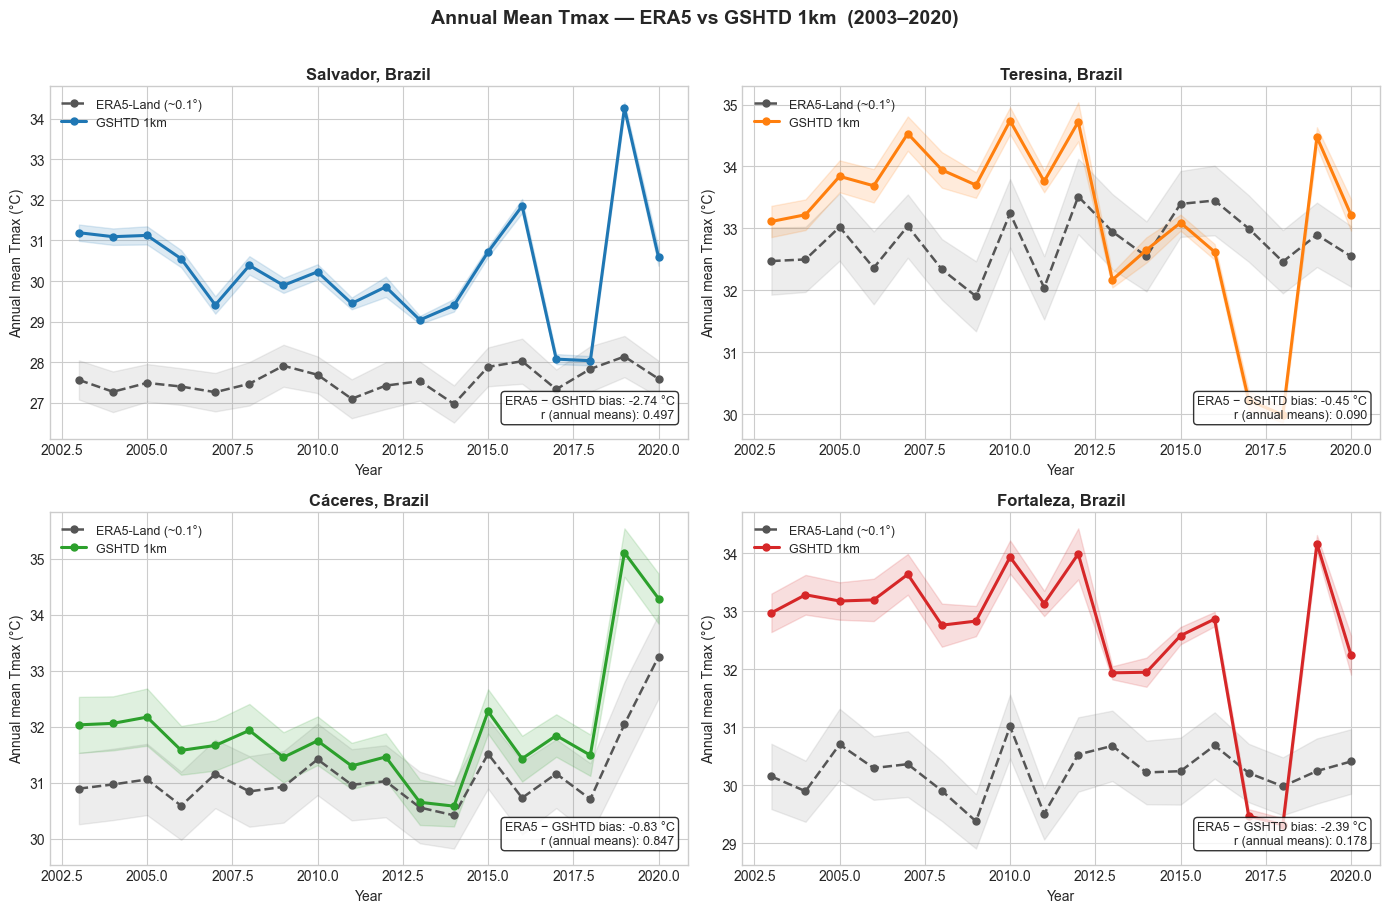

Saved 14_annual_tmax_era5_vs_gshtd.png


In [37]:
def _annual_mean(da: xr.DataArray) -> pd.Series:
    """Spatial mean, then annual mean of daily Tmax."""
    daily_mean = da.mean(["lat", "lon"])  # (time,)
    return daily_mean.groupby("time.year").mean().to_series()


def _annual_std(da: xr.DataArray) -> pd.Series:
    """Annual mean of spatial standard deviation (pixel spread)."""
    daily_std = da.std(["lat", "lon"])
    return daily_std.groupby("time.year").mean().to_series()


n_cities = len(AVAILABLE)
ncols = 2
nrows = (n_cities + 1) // 2

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4.5 * nrows), sharey=False)
axes = np.array(axes).ravel()

for ax, city in zip(axes, AVAILABLE):
    cfg   = COMPARISON_CITIES[city]
    color = CITY_COLORS[city]

    # ERA5 annual mean (area-mean over GSHTD footprint)
    era5_ann = _annual_mean(era5_in_bbox[city])
    era5_std = _annual_std(era5_in_bbox[city])

    # GSHTD 1km annual mean
    gshtd_ann = _annual_mean(gshtd_data[city])
    gshtd_std = _annual_std(gshtd_data[city])

    yrs = era5_ann.index.values

    # ERA5
    ax.fill_between(yrs, era5_ann - era5_std, era5_ann + era5_std,
                    alpha=0.15, color="#888888")
    ax.plot(yrs, era5_ann, "o--", color="#555555", lw=1.8, ms=5,
            label=f"ERA5-Land (~0.1°)")

    # GSHTD
    ax.fill_between(yrs, gshtd_ann - gshtd_std, gshtd_ann + gshtd_std,
                    alpha=0.15, color=color)
    ax.plot(yrs, gshtd_ann, "o-", color=color, lw=2.2, ms=5,
            label="GSHTD 1km")

    # Bias annotation
    # Align on common years
    common_yrs = era5_ann.index.intersection(gshtd_ann.index)
    bias = (era5_ann.loc[common_yrs] - gshtd_ann.loc[common_yrs]).mean()
    r    = np.corrcoef(era5_ann.loc[common_yrs], gshtd_ann.loc[common_yrs])[0, 1]
    ax.set_title(cfg["label"], fontsize=12, fontweight="bold")
    ax.set_xlabel("Year")
    ax.set_ylabel("Annual mean Tmax (°C)")
    ax.legend(loc="upper left", fontsize=9)
    ax.text(0.98, 0.05,
            f"ERA5 − GSHTD bias: {bias:+.2f} °C\nr (annual means): {r:.3f}",
            transform=ax.transAxes, ha="right", va="bottom",
            fontsize=9, bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8))

for ax in axes[n_cities:]:
    ax.set_visible(False)

fig.suptitle("Annual Mean Tmax — ERA5 vs GSHTD 1km  (2003–2020)",
             fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/14_annual_tmax_era5_vs_gshtd.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved 14_annual_tmax_era5_vs_gshtd.png")

## Section 5 — Seasonal Cycle (Monthly Climatology)

Long-term monthly mean Tmax (2003–2020 climatology) for both products.
The ERA5 seasonal cycle uses spatial-mean daily values; the GSHTD uses all 1km pixels.

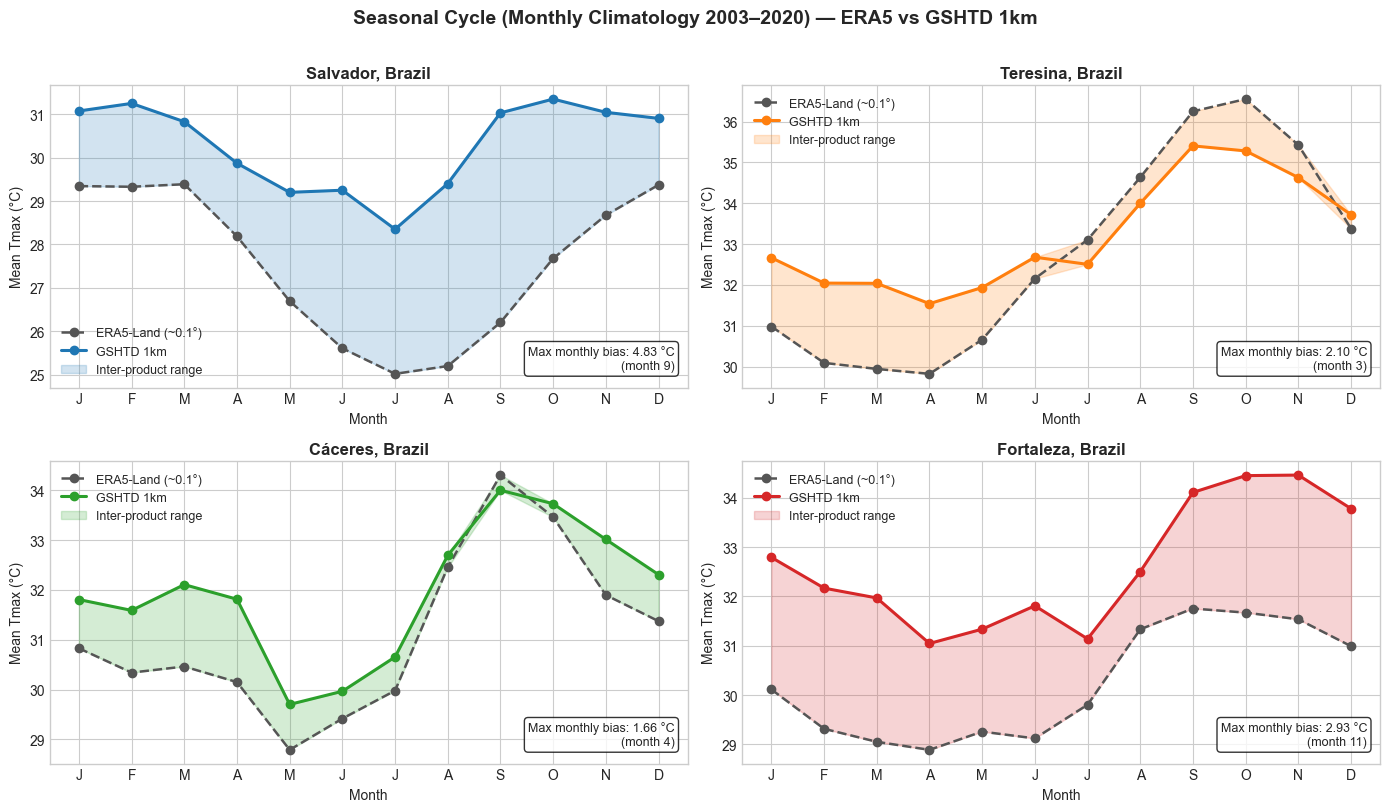

Saved 14_seasonal_cycle_era5_vs_gshtd.png


In [28]:
MONTH_LABELS = ["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"]

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows), sharey=False)
axes = np.array(axes).ravel()

for ax, city in zip(axes, AVAILABLE):
    cfg   = COMPARISON_CITIES[city]
    color = CITY_COLORS[city]

    era5_daily  = era5_in_bbox[city].mean(["lat", "lon"])
    gshtd_daily = gshtd_data[city].mean(["lat", "lon"])

    era5_clim  = era5_daily.groupby("time.month").mean().to_series()
    gshtd_clim = gshtd_daily.groupby("time.month").mean().to_series()

    months = np.arange(1, 13)

    ax.plot(months, era5_clim.values,  "o--", color="#555555", lw=1.8, ms=6,
            label="ERA5-Land (~0.1°)")
    ax.plot(months, gshtd_clim.values, "o-",  color=color,    lw=2.2, ms=6,
            label="GSHTD 1km")
    ax.fill_between(months,
                    np.minimum(era5_clim.values, gshtd_clim.values),
                    np.maximum(era5_clim.values, gshtd_clim.values),
                    alpha=0.2, color=color, label="Inter-product range")

    monthly_bias = (era5_clim - gshtd_clim)
    ax.set_xticks(months)
    ax.set_xticklabels(MONTH_LABELS)
    ax.set_title(cfg["label"], fontsize=12, fontweight="bold")
    ax.set_xlabel("Month")
    ax.set_ylabel("Mean Tmax (°C)")
    ax.legend(loc="best", fontsize=9)
    ax.text(0.98, 0.05,
            f"Max monthly bias: {monthly_bias.abs().max():.2f} °C\n"
            f"(month {monthly_bias.abs().idxmax()})",
            transform=ax.transAxes, ha="right", va="bottom",
            fontsize=9, bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8))

for ax in axes[n_cities:]:
    ax.set_visible(False)

fig.suptitle("Seasonal Cycle (Monthly Climatology 2003–2020) — ERA5 vs GSHTD 1km",
             fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/14_seasonal_cycle_era5_vs_gshtd.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved 14_seasonal_cycle_era5_vs_gshtd.png")

## Section 6 — Daily Correlation & Bias (Pixel-Level)

Uses the **block-averaged GSHTD** (on the ERA5-Land grid) for a pixel-level comparison.
Each scatter point is one ERA5-Land cell × day. Metrics:
- **Bias** = ERA5-Land − GSHTD_agg (mean offset)
- **RMSE** = root mean squared error
- **R²** = coefficient of determination (Pearson)

Because ERA5-Land is land-only, coastal pixels no longer mix ocean SST with land
temperature — expect meaningfully higher R² than with the old ERA5 (0.25°) product.

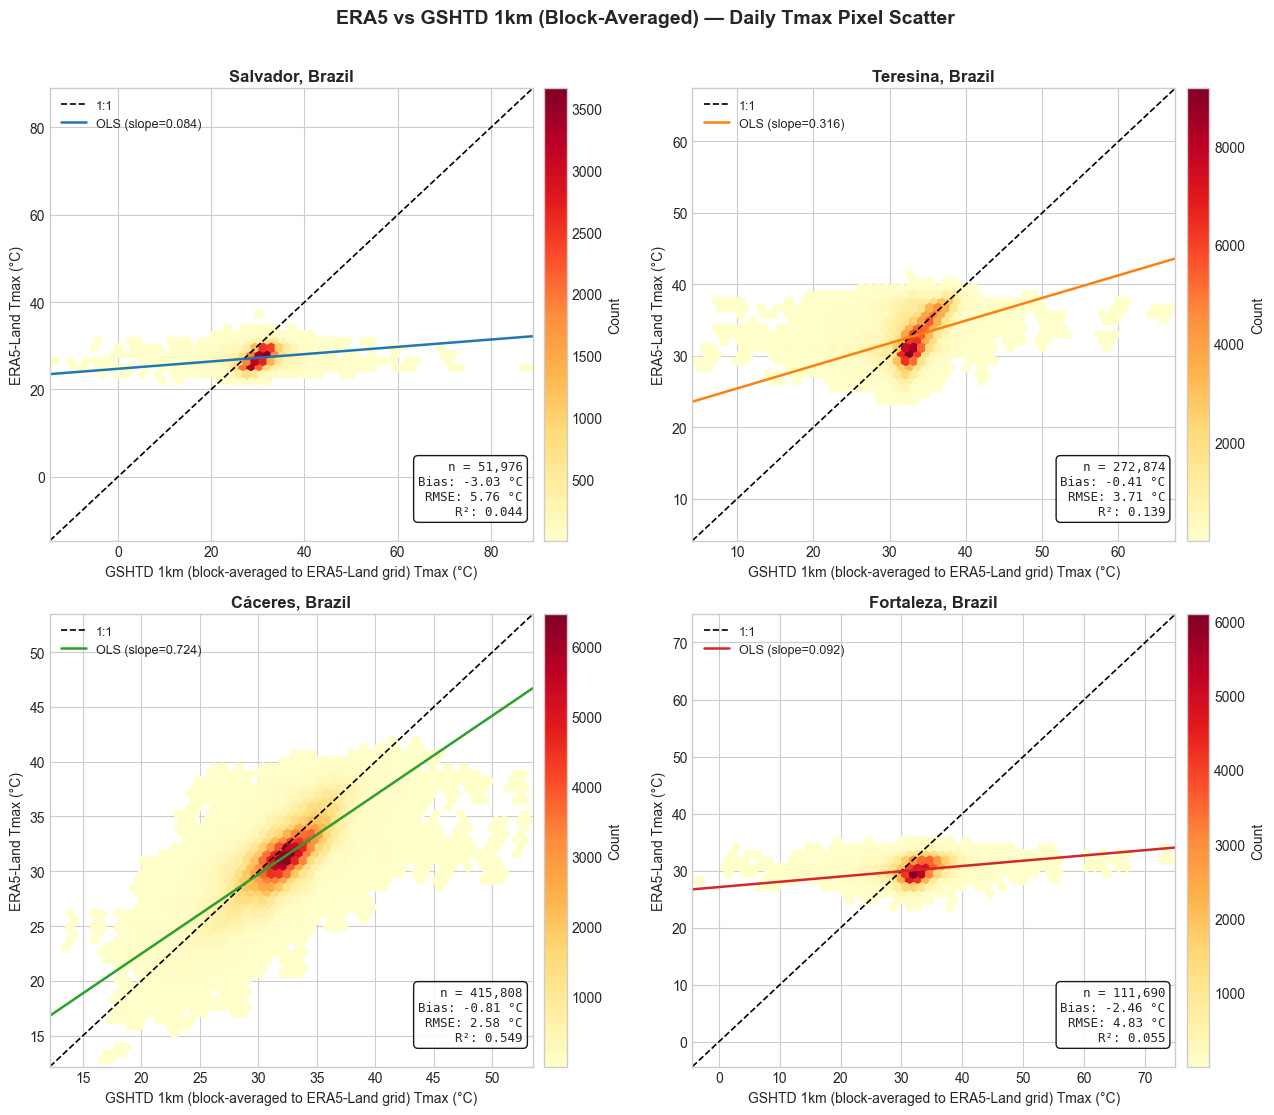

Saved 14_scatter_era5_vs_gshtd_agg.png

                   Bias (°C)  RMSE (°C)     R²  OLS slope  OLS intercept
City                                                                    
Salvador, Brazil      -3.032      5.756  0.044      0.084         24.729
Teresina, Brazil      -0.412      3.712  0.139      0.316         22.283
Cáceres, Brazil       -0.814      2.580  0.549      0.724          8.004
Fortaleza, Brazil     -2.460      4.832  0.055      0.092         27.134


In [36]:
fig, axes = plt.subplots(nrows, ncols, figsize=(13, 5.5 * nrows))
axes = np.array(axes).ravel()

summary_rows = []

for ax, city in zip(axes, AVAILABLE):
    cfg   = COMPARISON_CITIES[city]
    color = CITY_COLORS[city]

    era5_v  = era5_matched[city].values.ravel()
    gshtd_v = gshtd_agg[city].values.ravel()

    valid = np.isfinite(era5_v) & np.isfinite(gshtd_v)
    e, g  = era5_v[valid], gshtd_v[valid]

    bias = float(np.mean(e - g))
    rmse = float(np.sqrt(np.mean((e - g) ** 2)))
    r, _ = stats.pearsonr(e, g)

    # Density scatter (hexbin for speed with many points)
    lim_lo = min(e.min(), g.min()) - 0.5
    lim_hi = max(e.max(), g.max()) + 0.5
    hb = ax.hexbin(g, e, gridsize=60, cmap="YlOrRd", mincnt=1,
                   extent=[lim_lo, lim_hi, lim_lo, lim_hi])
    plt.colorbar(hb, ax=ax, label="Count", pad=0.02)

    # 1:1 line
    ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi], "k--", lw=1.2, label="1:1")

    # OLS regression line
    slope, intercept, *_ = stats.linregress(g, e)
    x_fit = np.array([lim_lo, lim_hi])
    ax.plot(x_fit, slope * x_fit + intercept, "-", color=color, lw=1.8,
            label=f"OLS (slope={slope:.3f})")

    ax.set_xlim(lim_lo, lim_hi)
    ax.set_ylim(lim_lo, lim_hi)
    ax.set_xlabel("GSHTD 1km (block-averaged to ERA5-Land grid) Tmax (°C)")
    ax.set_ylabel("ERA5-Land Tmax (°C)")
    ax.set_title(cfg["label"], fontsize=12, fontweight="bold")
    ax.legend(fontsize=9, loc="upper left")
    ax.text(0.98, 0.05,
            f"n = {valid.sum():,}\nBias: {bias:+.2f} °C\nRMSE: {rmse:.2f} °C\nR²: {r**2:.3f}",
            transform=ax.transAxes, ha="right", va="bottom",
            fontsize=9, family="monospace",
            bbox=dict(boxstyle="round,pad=0.35", fc="white", alpha=0.9))

    summary_rows.append({"City": cfg["label"], "Bias (°C)": bias,
                          "RMSE (°C)": rmse, "R²": r ** 2,
                          "OLS slope": slope, "OLS intercept": intercept})

for ax in axes[n_cities:]:
    ax.set_visible(False)

fig.suptitle("ERA5 vs GSHTD 1km (Block-Averaged) — Daily Tmax Pixel Scatter",
             fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/14_scatter_era5_vs_gshtd_agg.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved 14_scatter_era5_vs_gshtd_agg.png\n")

summary_df = pd.DataFrame(summary_rows).set_index("City")
print(summary_df.round(3).to_string())

## Section 7 — Trend Analysis (2003–2020)

Estimates the long-term warming trend in annual mean area-averaged Tmax using
**Sen's slope** (Theil-Sen estimator), which is robust to outlier years.
Confidence intervals are computed via the Mann-Kendall test.

Comparing ERA5-Land and GSHTD trend slopes reveals whether the statistical downscaling
preserves or modifies the warming signal.

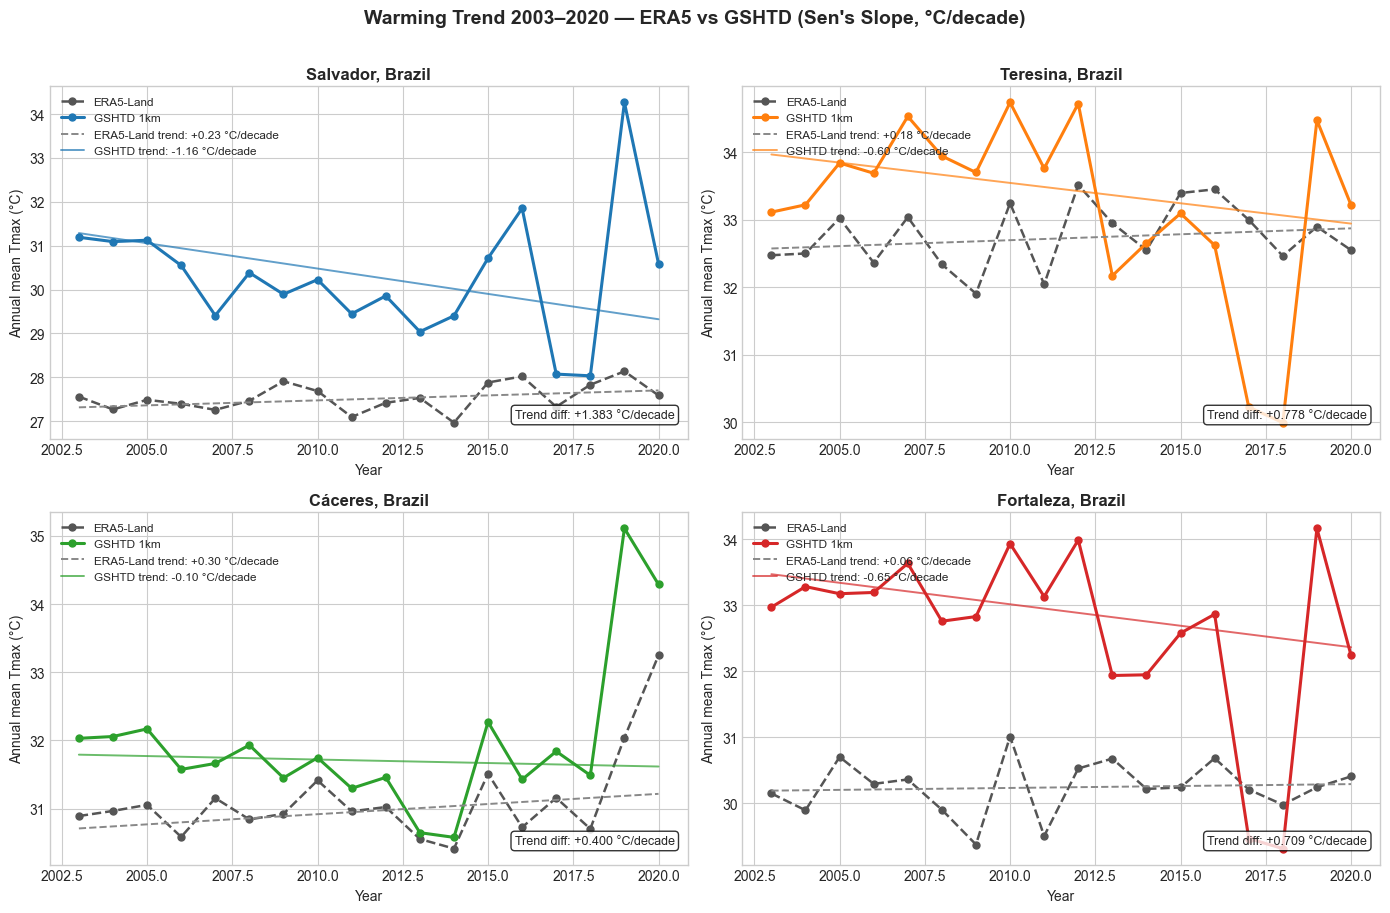

Saved 14_trend_era5_vs_gshtd.png

                   ERA5 trend (°C/dec)  GSHTD trend (°C/dec)  Diff (°C/dec)
City                                                                       
Salvador, Brazil                 0.227                -1.156          1.383
Teresina, Brazil                 0.176                -0.603          0.778
Cáceres, Brazil                  0.298                -0.102          0.400
Fortaleza, Brazil                0.058                -0.650          0.709


In [33]:
def sens_slope(values: np.ndarray) -> tuple[float, float]:
    """Theil-Sen slope and intercept (°C/year)."""
    x = np.arange(len(values), dtype=float)
    result = stats.theilslopes(values, x)
    return float(result.slope), float(result.intercept)


fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4.5 * nrows))
axes = np.array(axes).ravel()

trend_rows = []

for ax, city in zip(axes, AVAILABLE):
    cfg   = COMPARISON_CITIES[city]
    color = CITY_COLORS[city]

    era5_ann  = _annual_mean(era5_in_bbox[city])
    gshtd_ann = _annual_mean(gshtd_data[city])

    common_yrs  = era5_ann.index.intersection(gshtd_ann.index)
    era5_vals   = era5_ann.loc[common_yrs].values
    gshtd_vals  = gshtd_ann.loc[common_yrs].values
    yrs         = common_yrs.values.astype(float)
    x_norm      = yrs - yrs[0]  # 0-indexed years for sens_slope

    era5_s,  era5_i  = sens_slope(era5_vals)
    gshtd_s, gshtd_i = sens_slope(gshtd_vals)

    ax.plot(common_yrs, era5_vals,  "o--", color="#555555", lw=1.8, ms=5,
            label="ERA5-Land")
    ax.plot(common_yrs, gshtd_vals, "o-",  color=color,    lw=2.2, ms=5,
            label="GSHTD 1km")

    ax.plot(common_yrs, era5_i  + era5_s  * x_norm, "--", color="#888888", lw=1.4,
            label=f"ERA5-Land trend: {era5_s*10:+.2f} °C/decade")
    ax.plot(common_yrs, gshtd_i + gshtd_s * x_norm, "-",  color=color,    lw=1.4, alpha=0.7,
            label=f"GSHTD trend: {gshtd_s*10:+.2f} °C/decade")

    ax.set_title(cfg["label"], fontsize=12, fontweight="bold")
    ax.set_xlabel("Year")
    ax.set_ylabel("Annual mean Tmax (°C)")
    ax.legend(fontsize=8.5, loc="upper left")
    ax.text(0.98, 0.05,
            f"Trend diff: {(era5_s - gshtd_s)*10:+.3f} °C/decade",
            transform=ax.transAxes, ha="right", va="bottom",
            fontsize=9, bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8))

    trend_rows.append({
        "City": cfg["label"],
        "ERA5 trend (°C/dec)": round(era5_s * 10, 3),
        "GSHTD trend (°C/dec)": round(gshtd_s * 10, 3),
        "Diff (°C/dec)": round((era5_s - gshtd_s) * 10, 3),
    })

for ax in axes[n_cities:]:
    ax.set_visible(False)

fig.suptitle("Warming Trend 2003–2020 — ERA5 vs GSHTD (Sen's Slope, °C/decade)",
             fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/14_trend_era5_vs_gshtd.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved 14_trend_era5_vs_gshtd.png\n")

trend_df = pd.DataFrame(trend_rows).set_index("City")
print(trend_df.to_string())

## Section 8 — Spatial Resolution Comparison (Salvador Example)

Side-by-side maps for a single representative year showing:
- **Left**: ERA5-Land pixel grid (~0.1° / ~9 km), land pixels only
- **Centre**: GSHTD 1km pixel grid
- **Right**: GSHTD block-averaged to ERA5-Land grid

Salvador is used as a representative example because its coastal setting creates
strong spatial gradients. With ERA5-Land the coastal land/sea mixing problem is
eliminated — ocean pixels are simply absent from the ERA5-Land grid.

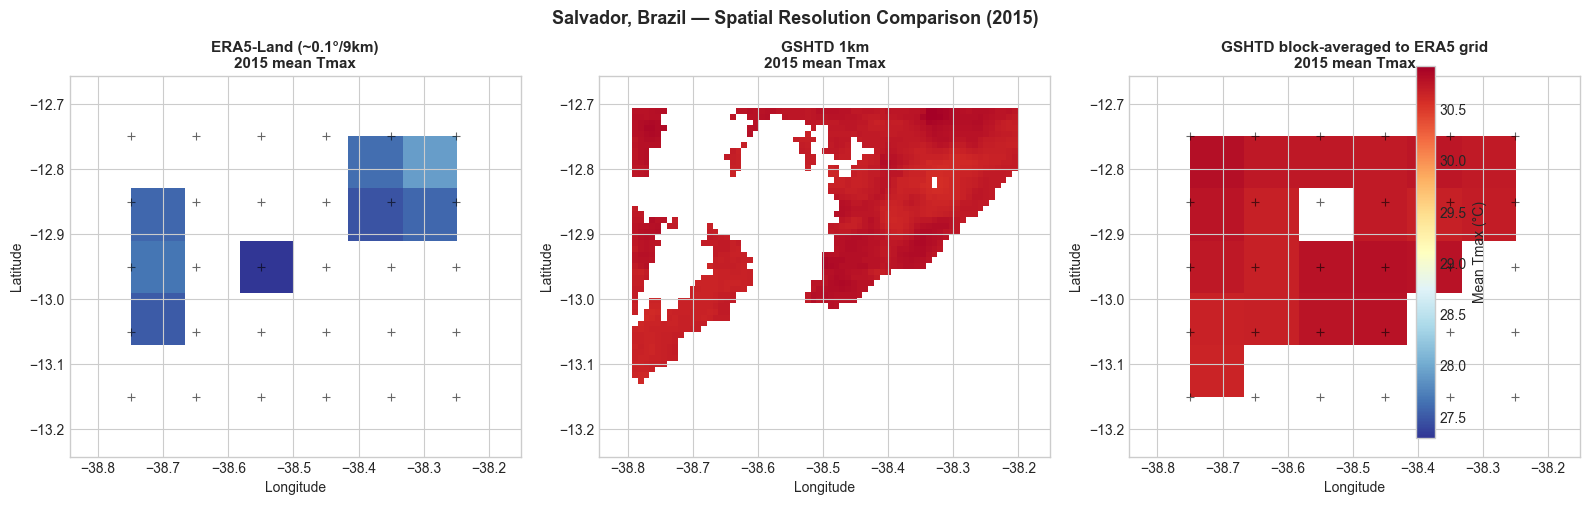

Saved 14_spatial_comparison_salvador_2015.png


In [34]:
EXAMPLE_CITY = "salvador"   # change to any city in AVAILABLE
EXAMPLE_YEAR = 2015

if EXAMPLE_CITY not in AVAILABLE:
    print(f"{EXAMPLE_CITY} not available — skipping spatial map.")
else:
    cfg = COMPARISON_CITIES[EXAMPLE_CITY]

    # Annual mean Tmax maps
    era5_map   = era5_matched[EXAMPLE_CITY].sel(
                     time=str(EXAMPLE_YEAR)).mean("time")         # (lat, lon)
    gshtd_map  = gshtd_data[EXAMPLE_CITY].sel(
                     time=str(EXAMPLE_YEAR)).mean("time")
    gshtd_agg_map = gshtd_agg[EXAMPLE_CITY].sel(
                     time=str(EXAMPLE_YEAR)).mean("time")

    # Shared colour limits
    vmin = float(min(era5_map.min(), gshtd_map.min()))
    vmax = float(max(era5_map.max(), gshtd_map.max()))

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    def _imshow(ax, data, title, mark_pixels=False):
        im = ax.imshow(
            data.values,
            extent=[float(data.lon.min()), float(data.lon.max()),
                    float(data.lat.min()), float(data.lat.max())],
            origin="lower", aspect="equal",
            cmap="RdYlBu_r", vmin=vmin, vmax=vmax,
        )
        if mark_pixels:
            for lat_v in data.lat.values:
                for lon_v in data.lon.values:
                    ax.plot(lon_v, lat_v, "k+", ms=6, mew=0.8, alpha=0.6)
        ax.set_title(title, fontsize=11, fontweight="bold")
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        return im

    im0 = _imshow(axes[0], era5_map,
                  f"ERA5-Land (~0.1°/9km)\n{EXAMPLE_YEAR} mean Tmax",
                  mark_pixels=True)
    im1 = _imshow(axes[1], gshtd_map,
                  f"GSHTD 1km\n{EXAMPLE_YEAR} mean Tmax")
    im2 = _imshow(axes[2], gshtd_agg_map,
                  f"GSHTD block-averaged to ERA5 grid\n{EXAMPLE_YEAR} mean Tmax",
                  mark_pixels=True)

    for ax in axes:
        ax.set_xlim(float(gshtd_map.lon.min()) - 0.05,
                    float(gshtd_map.lon.max()) + 0.05)
        ax.set_ylim(float(gshtd_map.lat.min()) - 0.05,
                    float(gshtd_map.lat.max()) + 0.05)

    plt.colorbar(im1, ax=axes, label="Mean Tmax (°C)", fraction=0.015, pad=0.04)
    fig.suptitle(
        f"{cfg['label']} — Spatial Resolution Comparison ({EXAMPLE_YEAR})",
        fontsize=13, fontweight="bold"
    )
    fig.tight_layout()
    fig.savefig(f"{OUTPUT_DIR}/14_spatial_comparison_{EXAMPLE_CITY}_{EXAMPLE_YEAR}.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved 14_spatial_comparison_{EXAMPLE_CITY}_{EXAMPLE_YEAR}.png")

## Section 9 — Summary Dashboard

4-panel cross-city comparison:
1. ERA5 bias vs GSHTD (mean over 2003–2020)
2. Day-to-day R² (pixel-level, block-averaged GSHTD)
3. Trend comparison (ERA5 vs GSHTD, Sen's slope °C/decade)
4. Peak-month spread (amplitude of seasonal cycle)

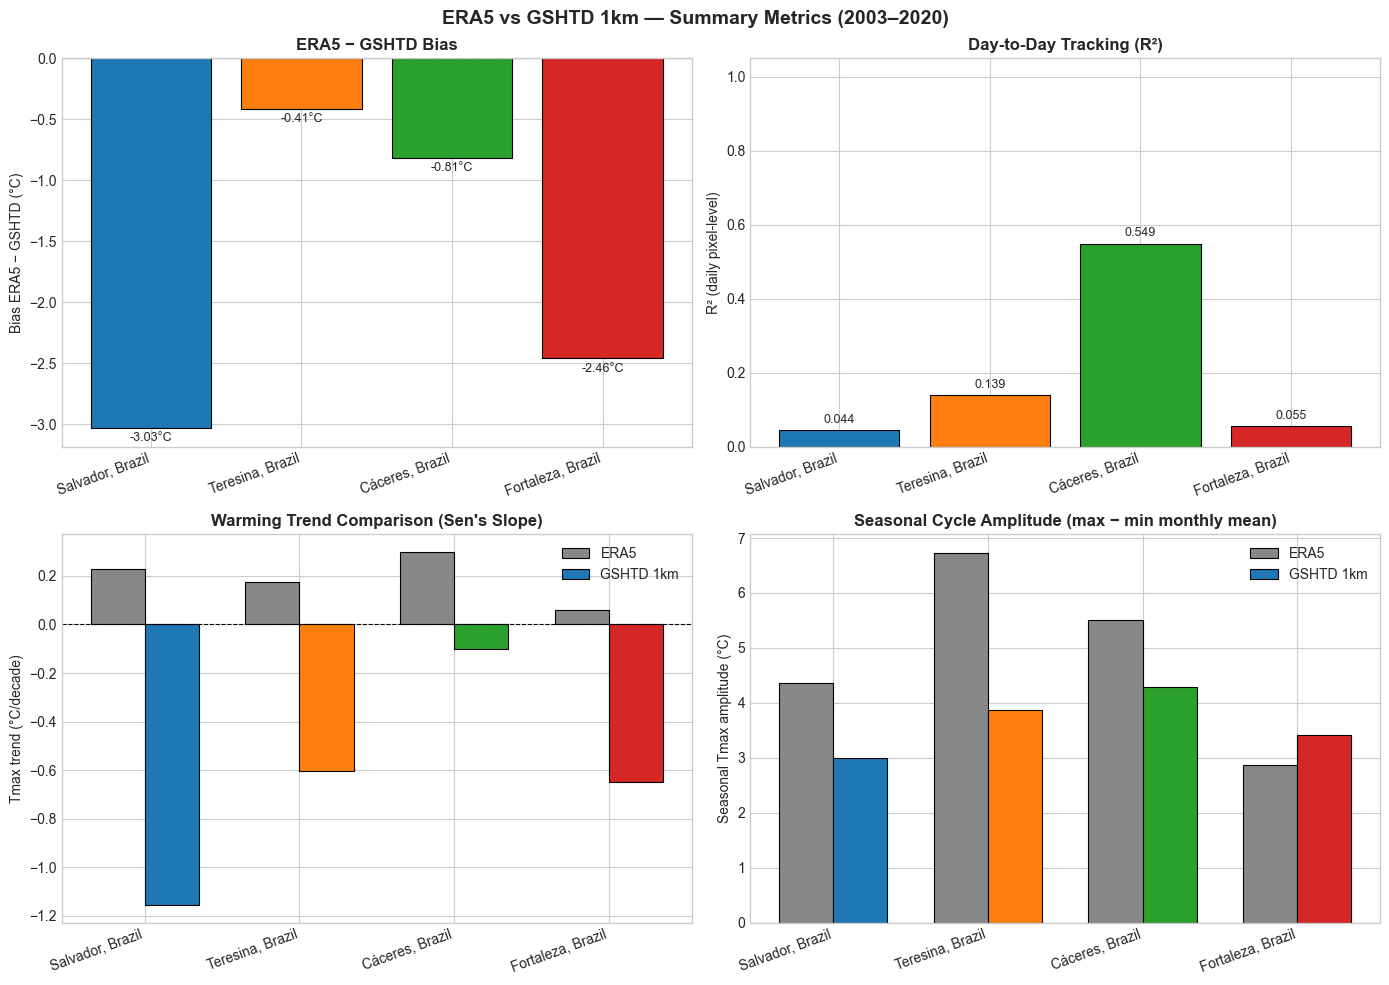

Saved 14_summary_dashboard_era5_vs_gshtd.png


In [35]:
city_labels = [COMPARISON_CITIES[c]["label"] for c in AVAILABLE]
colors_list = [CITY_COLORS[c] for c in AVAILABLE]

# ── Collect metrics ──────────────────────────────────────────────────────────
biases, r2s, era5_trends, gshtd_trends, amp_era5, amp_gshtd = [], [], [], [], [], []

for city in AVAILABLE:
    e_v = era5_matched[city].values.ravel()
    g_v = gshtd_agg[city].values.ravel()
    valid = np.isfinite(e_v) & np.isfinite(g_v)
    biases.append(float(np.mean(e_v[valid] - g_v[valid])))
    r, _ = stats.pearsonr(e_v[valid], g_v[valid])
    r2s.append(r ** 2)

    era5_ann  = _annual_mean(era5_in_bbox[city])
    gshtd_ann = _annual_mean(gshtd_data[city])
    common    = era5_ann.index.intersection(gshtd_ann.index)
    es, _  = sens_slope(era5_ann.loc[common].values)
    gs, _  = sens_slope(gshtd_ann.loc[common].values)
    era5_trends.append(es * 10)
    gshtd_trends.append(gs * 10)

    e_daily = era5_in_bbox[city].mean(["lat", "lon"])
    g_daily = gshtd_data[city].mean(["lat", "lon"])
    amp_era5.append(
        float(e_daily.groupby("time.month").mean().max() -
              e_daily.groupby("time.month").mean().min())
    )
    amp_gshtd.append(
        float(g_daily.groupby("time.month").mean().max() -
              g_daily.groupby("time.month").mean().min())
    )

x = np.arange(len(AVAILABLE))
w = 0.35

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── Panel 1: Bias ──────────────────────────────────────────────────────────
ax = axes[0, 0]
bars = ax.bar(x, biases, color=colors_list, edgecolor="k", linewidth=0.8)
ax.axhline(0, color="k", lw=0.8, ls="--")
ax.bar_label(bars, fmt="{:.2f}°C", padding=3, fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(city_labels, rotation=20, ha="right")
ax.set_ylabel("Bias ERA5 − GSHTD (°C)")
ax.set_title("ERA5 − GSHTD Bias", fontweight="bold")

# ── Panel 2: R² ───────────────────────────────────────────────────────────
ax = axes[0, 1]
bars = ax.bar(x, r2s, color=colors_list, edgecolor="k", linewidth=0.8)
ax.bar_label(bars, fmt="{:.3f}", padding=3, fontsize=9)
ax.set_ylim(0, 1.05)
ax.set_xticks(x)
ax.set_xticklabels(city_labels, rotation=20, ha="right")
ax.set_ylabel("R² (daily pixel-level)")
ax.set_title("Day-to-Day Tracking (R²)", fontweight="bold")

# ── Panel 3: Trends ───────────────────────────────────────────────────────
ax = axes[1, 0]
ax.bar(x - w / 2, era5_trends,  w, color="#888888", edgecolor="k", lw=0.8, label="ERA5")
ax.bar(x + w / 2, gshtd_trends, w, color=colors_list, edgecolor="k", lw=0.8, label="GSHTD 1km")
ax.axhline(0, color="k", lw=0.8, ls="--")
ax.set_xticks(x)
ax.set_xticklabels(city_labels, rotation=20, ha="right")
ax.set_ylabel("Tmax trend (°C/decade)")
ax.set_title("Warming Trend Comparison (Sen's Slope)", fontweight="bold")
ax.legend()

# ── Panel 4: Seasonal amplitude ───────────────────────────────────────────
ax = axes[1, 1]
ax.bar(x - w / 2, amp_era5,  w, color="#888888", edgecolor="k", lw=0.8, label="ERA5")
ax.bar(x + w / 2, amp_gshtd, w, color=colors_list, edgecolor="k", lw=0.8, label="GSHTD 1km")
ax.set_xticks(x)
ax.set_xticklabels(city_labels, rotation=20, ha="right")
ax.set_ylabel("Seasonal Tmax amplitude (°C)")
ax.set_title("Seasonal Cycle Amplitude (max − min monthly mean)", fontweight="bold")
ax.legend()

fig.suptitle("ERA5 vs GSHTD 1km — Summary Metrics (2003–2020)",
             fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/14_summary_dashboard_era5_vs_gshtd.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved 14_summary_dashboard_era5_vs_gshtd.png")

## Interpretation Notes

| What to look for | What it means |
|---|---|
| **Bias ≈ 0** | ERA5-Land and GSHTD agree on the mean temperature level |
| **R² close to 1** | Both products track the same day-to-day variability |
| **Trend agreement** | Both products agree on the sign and magnitude of long-term warming |
| **Seasonal amplitude difference** | One product has a sharper or flatter intra-annual cycle |
| **Spatial maps**: ERA5-Land tiles vs GSHTD gradients | 1km resolves urban/topographic gradients invisible at 9km |

### Key caveats

- ERA5-Land daily max is computed as the maximum of 24 UTC hourly values. For UTC-3 cities
  (Brazil), this window spans the full local day with only minor edge effects.
- Persistent negative bias (ERA5-Land colder than GSHTD) at the coastal cities Salvador and
  Fortaleza is likely a scale effect: ERA5-Land 9km pixels average over a wider land area
  including cooler suburban and peri-urban land, whereas GSHTD 1km is anchored to station
  observations that skew towards warmer urban locations.
- The block-average aggregation assigns GSHTD pixels to ERA5-Land cells based on cell-centre
  midpoints; a more rigorous approach (area-weighted regridding) would require `xesmf`.
- The GSHTD cooling trends (-0.1 to -1.2 °C/decade) while ERA5-Land shows warming
  (+0.1 to +0.3 °C/decade) is the most notable divergence and warrants investigation —
  see Section 7 for details.